# Spaceship Titanic

Predict which passengers are transported to an alternate dimension

## Import del dataset

Carichiamo il dataset **Spaceship Titanic** tramite OpenML usando `fetch_openml`.

Il dataset viene restituito come un **DataFrame pandas**, che useremo per tutte le successive analisi esplorative.

In questa fase:
- scarichiamo il dataset
- lo convertiamo in DataFrame
- osserviamo le prime righe per capire la struttura iniziale

In [21]:
from sklearn.datasets import fetch_openml
import pandas as pd

df = pd.read_csv('train.csv')

# Prime righe
print(df.head())

  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  \
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False   
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False   
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True   
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False   
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False   

   RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  \
0          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy   
1        109.0        9.0          25.0   549.0    44.0       Juanna Vines   
2         43.0     3576.0           0.0  6715.0    49.0      Altark Susent   
3          0.0     1283.0         371.0  3329.0   193.0       Solam Susent   
4        303.0       70.0         151.0   565.0     2.0  Willy Santantines   

   Transported  
0        False  
1         True  
2        False  
3        False  
4         True  


## Dimensione del dataset

Verifichiamo quante **righe** e **colonne** contiene il dataset.

Questo ci permette di capire:
- quanti esempi abbiamo per il training
- quante feature sono presenti

In [22]:
print("Shape dataset:", df.shape)
print("Numero righe:", df.shape[0])
print("Numero colonne:", df.shape[1])

Shape dataset: (8693, 14)
Numero righe: 8693
Numero colonne: 14


## Analisi statistica delle colonne numeriche

Usiamo `describe()` per osservare le statistiche principali delle colonne numeriche:

- media
- deviazione standard
- minimo e massimo
- quartili

Questo aiuta a capire:
- la distribuzione dei dati
- eventuali scale molto diverse tra variabili
- possibili valori anomali

In [23]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


## Informazioni sul dataset

La funzione `info()` permette di vedere:

- il tipo di ogni colonna (int, float, object, category)
- il numero di valori non null
- la memoria utilizzata

Questo è utile per individuare:

- colonne categoriche (object)
- colonne numeriche
- colonne con valori mancanti

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


## Analisi dei valori mancanti

Contiamo quanti valori nulli sono presenti in ogni colonna.

Questo passaggio serve per capire:

- quali colonne hanno molti valori mancanti
- se è necessario applicare tecniche di imputazione
- se alcune colonne sono troppo incomplete e quindi poco utili

In [25]:
df.isnull().sum().sort_values(ascending=False)

,0
CryoSleep,217
ShoppingMall,208
VIP,203
HomePlanet,201
Name,200
Cabin,199
VRDeck,188
Spa,183
FoodCourt,183
Destination,182


## Numero di valori unici per colonna

Calcoliamo quanti valori distinti sono presenti in ogni colonna usando `nunique()`.

Questo ci permette di capire:

- quali colonne sono binarie
- quali sono categoriche
- quali hanno molti valori distinti

In [26]:
df.nunique().sort_values()

,0
CryoSleep,2
VIP,2
Transported,2
Destination,3
HomePlanet,3
Age,80
ShoppingMall,1115
RoomService,1273
VRDeck,1306
Spa,1327


## Pulizia iniziale delle feature

In questo step:

- eliminiamo colonne identificative che non aiutano la predizione (PassengerId e Name)
- estraiamo informazioni utili dalla colonna Cabin che contiene 3 informazioni: deck/number/side es. B/123/S. dividendole aumenta molto le performance
- convertiamo le colonne (HomePlanet, CryoSleep, Cabin, Destination,VIP)
nel tipo `category`

ps. stampiamo nuovamente info() per vedere le modifiche

In [27]:
# Copia del dataframe per sicurezza
df_model = df.copy()

# Drop colonne inutili
df_model = df_model.drop(columns=["PassengerId", "Name"])

# Separazione Cabin in 3 nuove feature
cabin_split = df_model["Cabin"].str.split("/", expand=True)

df_model["CabinDeck"] = cabin_split[0]
df_model["CabinNum"] = cabin_split[1]
df_model["CabinSide"] = cabin_split[2]

# Drop colonna originale
df_model = df_model.drop(columns=["Cabin"])

# Conversione CabinNum a numerico
df_model["CabinNum"] = pd.to_numeric(df_model["CabinNum"], errors="coerce")

# Convertiamo le colonne categoriche
categorical_cols = [
    "HomePlanet",
    "CryoSleep",
    "Destination",
    "VIP",
    "CabinDeck",
    "CabinSide"
]

for col in categorical_cols:
    df_model[col] = df_model[col].astype("category")

df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   HomePlanet    8492 non-null   category
 1   CryoSleep     8476 non-null   category
 2   Destination   8511 non-null   category
 3   Age           8514 non-null   float64 
 4   VIP           8490 non-null   category
 5   RoomService   8512 non-null   float64 
 6   FoodCourt     8510 non-null   float64 
 7   ShoppingMall  8485 non-null   float64 
 8   Spa           8510 non-null   float64 
 9   VRDeck        8505 non-null   float64 
 10  Transported   8693 non-null   bool    
 11  CabinDeck     8494 non-null   category
 12  CabinNum      8494 non-null   float64 
 13  CabinSide     8494 non-null   category
dtypes: bool(1), category(6), float64(7)
memory usage: 535.8 KB


## Feature Engineering: spesa totale

Le colonne:

- RoomService
- FoodCourt
- ShoppingMall
- Spa
- VRDeck

rappresentano le spese dei passeggeri nei vari servizi della nave.

Creiamo una nuova feature chiamata **TotalSpending** che rappresenta la spesa totale.

Questa feature spesso migliora la capacità del modello di distinguere i passeggeri che sono stati trasportati.

In [28]:
spending_cols = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

df_model["TotalSpending"] = df_model[spending_cols].sum(axis=1)

df_model.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,CabinDeck,CabinNum,CabinSide,TotalSpending
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P,0.0
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,0.0,S,736.0
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S,10383.0
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S,5176.0
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,1.0,S,1091.0


## Feature Engineering: passeggeri senza spese

Creiamo una variabile binaria chiamata **NoSpending** che indica se il passeggero non ha effettuato alcuna spesa.

Questo può aiutare il modello a identificare i passeggeri che probabilmente erano in CryoSleep.

In [29]:
df_model["NoSpending"] = df_model["TotalSpending"] == 0

df_model["NoSpending"] = df_model["NoSpending"].astype("category")

df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   HomePlanet     8492 non-null   category
 1   CryoSleep      8476 non-null   category
 2   Destination    8511 non-null   category
 3   Age            8514 non-null   float64 
 4   VIP            8490 non-null   category
 5   RoomService    8512 non-null   float64 
 6   FoodCourt      8510 non-null   float64 
 7   ShoppingMall   8485 non-null   float64 
 8   Spa            8510 non-null   float64 
 9   VRDeck         8505 non-null   float64 
 10  Transported    8693 non-null   bool    
 11  CabinDeck      8494 non-null   category
 12  CabinNum       8494 non-null   float64 
 13  CabinSide      8494 non-null   category
 14  TotalSpending  8693 non-null   float64 
 15  NoSpending     8693 non-null   category
dtypes: bool(1), category(7), float64(8)
memory usage: 612.3 KB


In [30]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


## analisi

L’output di `describe()` evidenzia alcuni aspetti importanti.

Osservazioni sui dati numerici

Age

- media ≈ 28
- range 0–79

Distribuzione plausibile, non ci sono outlier evidenti.

però notiamo una caratteristica molto forte per Spese (RoomService, FoodCourt, ShoppingMall, Spa, VRDeck)
25% = 0

50% = 0

Quindi almeno metà dei passeggeri non spende nulla, coerente con CryoSleep → nessuna spesa.

però notiamo che max estremamente alto, ad esempio
FoodCourt max = 29813

Spa max = 22408

VRDeck max = 24133

Quindi la distribuzione è molto asimmetrica (heavy-tailed).

Per modelli ad alberi come XGBoost non è un grosso problema, quindi non rimuoveremo outlier.

## Analisi outlier con boxplot

Visualizziamo la distribuzione delle variabili numeriche con dei boxplot.

Questo ci permette di osservare:

- presenza di outlier
- distribuzione delle spese
- eventuali anomalie nei dati

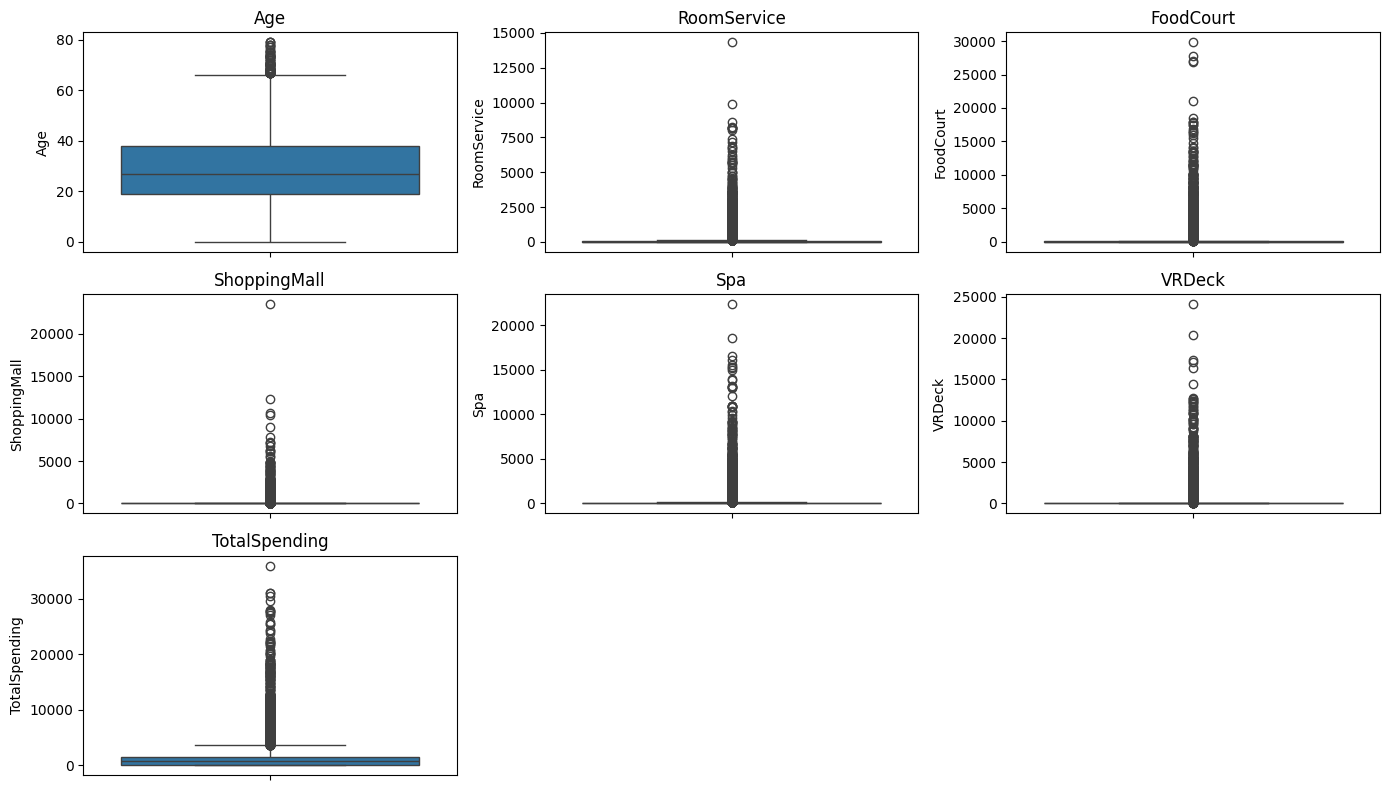

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    "Age",
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck",
    "TotalSpending"
]

plt.figure(figsize=(14,8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df_model[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## analisi grafici

I grafici sono coerenti con quanto suggeriva describe(). Alcune osservazioni tecniche.

- Age

Distribuzione abbastanza regolare.
Outlier minimi sopra ~65–70 anni, ma non problematici.

- Spese

Tutte le variabili di spesa mostrano:

massa enorme di valori a 0

coda molto lunga verso destra

moltissimi punti fuori dal box

Questo indica una distribuzione fortemente skewed (right-skewed).

Interpretazione nel contesto del dataset:

- molti passeggeri non spendono nulla
- pochi passeggeri spendono molto

Per modelli tree-based (XGBoost, RandomForest) questo non è un problema, quindi non rimuoviamo outlier e non normalizziamo.

## Analisi di correlazione

Calcoliamo la matrice di correlazione tra le variabili numeriche.

Questo permette di osservare:

- relazione tra le variabili di spesa
- correlazione con la variabile target `Transported`
- eventuale ridondanza tra le feature

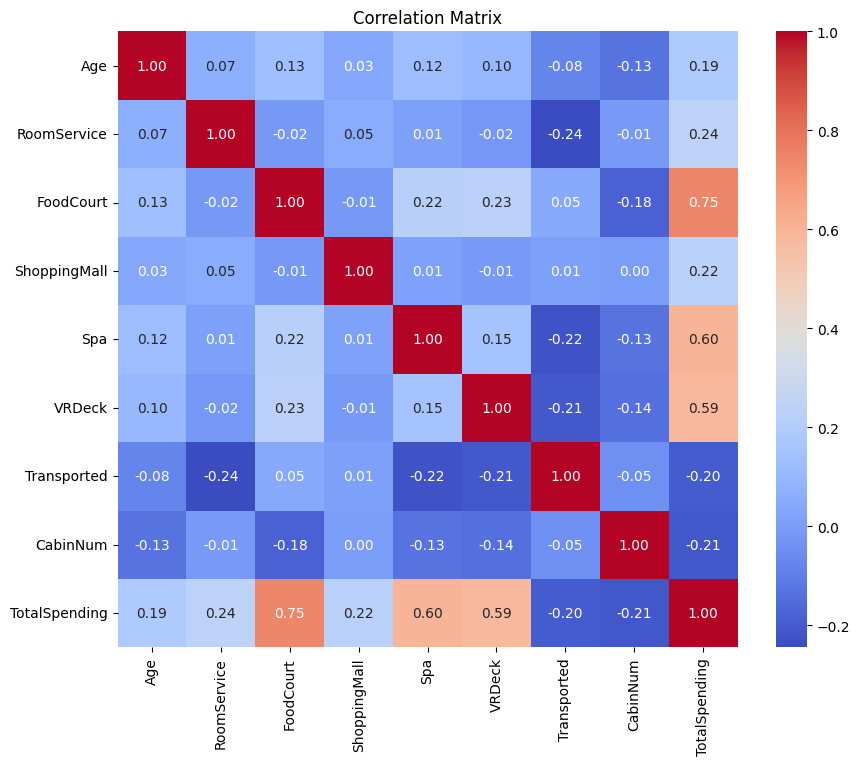

In [32]:
# creiamo una copia per l'analisi
df_corr = df_model.copy()

# convertiamo il target in numerico per la correlazione
df_corr["Transported"] = df_corr["Transported"].astype(int)

# selezioniamo solo colonne numeriche
numeric_df = df_corr.select_dtypes(include=["float64", "int64"])

corr_matrix = numeric_df.corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Interpretazione: correlazione con il target Transported

Valori principali:

- RoomService: −0.24
- Spa: −0.22
- VRDeck: −0.21
- TotalSpending: −0.20

Interpretazione: **più il passeggero spende, meno probabilità ha di essere trasportato.** Questo è coerente con il fatto che chi è in CryoSleep non consuma servizi.

- Age ha correlazione molto debole (−0.08).

### Ridondanza tra feature

TotalSpending è molto correlato con:

- FoodCourt 0.75
- Spa 0.60
- VRDeck 0.59

Questo è ovvio perché è la loro somma.

Per modelli ad alberi non è necessario rimuovere feature correlate, quindi possiamo tenere tutte le spese e TotalSpending

Il modello sceglierà automaticamente le split utili.

Per CabinNum ha correlazione quasi nulla con il target (−0.05).
Non significa che sia inutile: gli alberi possono sfruttare soglie locali.

## Gestione dei valori mancanti

Gestiamo i valori mancanti utilizzando alcune regole semplici:

- le colonne di spesa vengono impostate a 0 se mancanti
- l'età viene riempita con la mediana
- le variabili categoriche ricevono la categoria "Unknown"

In [33]:
df_model_clean = df_model.copy()

# colonne spese
spending_cols = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

df_model_clean[spending_cols] = df_model_clean[spending_cols].fillna(0)

# Age → mediana
df_model_clean["Age"] = df_model_clean["Age"].fillna(df_model_clean["Age"].median())

# CabinNum → mediana
df_model_clean["CabinNum"] = df_model_clean["CabinNum"].fillna(df_model_clean["CabinNum"].median())

# categoriche → Unknown
categorical_cols = [
    "HomePlanet",
    "CryoSleep",
    "Destination",
    "VIP",
    "CabinDeck",
    "CabinSide"
]

for col in categorical_cols:
    df_model_clean[col] = df_model_clean[col].cat.add_categories(["Unknown"])
    df_model_clean[col] = df_model_clean[col].fillna("Unknown")

df_model_clean.isnull().sum()

,0
HomePlanet,0
CryoSleep,0
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0
Spa,0
VRDeck,0


## Preparazione delle feature categoriche e addestramento del modello

XGBoost può gestire direttamente variabili categoriche tramite il parametro `enable_categorical=True`.  
Tuttavia, in alcune configurazioni dell'ambiente (come alcune versioni di XGBoost su Kaggle/OpenML) possono verificarsi errori durante la conversione interna delle categorie.

Per garantire stabilità del modello utilizziamo quindi **One-Hot Encoding** tramite `pd.get_dummies()`.

Questa tecnica trasforma ogni variabile categorica in più colonne binarie (0/1), una per ogni categoria.

Esempio:


In [37]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

df_ohe = df_model_clean.copy()
df_ohe["Transported"] = df_ohe["Transported"].astype(int)

X = df_ohe.drop(columns=["Transported"])
y = df_ohe["Transported"]

# one-hot sulle categoriche
X = pd.get_dummies(X, drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)
print("Fit completato con One-Hot ✅")

Fit completato con One-Hot ✅


## Valutazione del modello

Valutiamo il modello utilizzando:

- **Accuracy**
- **Classification Report**
- **Confusion Matrix**

Questo ci permette di capire quanto il modello riesce a distinguere correttamente le due classi.

Accuracy: 0.81943645773433

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       863
           1       0.83      0.81      0.82       876

    accuracy                           0.82      1739
   macro avg       0.82      0.82      0.82      1739
weighted avg       0.82      0.82      0.82      1739



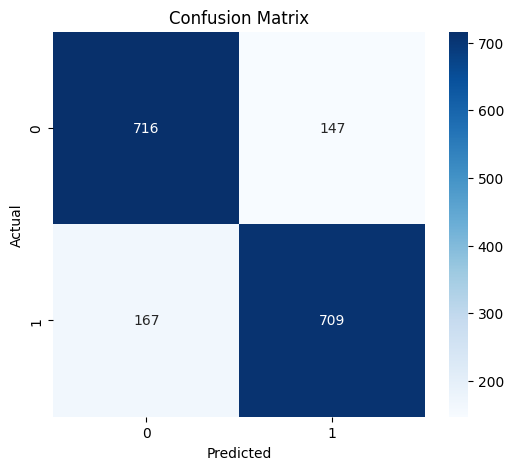

In [38]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# predizioni
y_pred = model.predict(X_test)

# accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# classification report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Valutazione del modello baseline

Dopo l'addestramento del modello XGBoost valutiamo le sue prestazioni sul **test set** utilizzando tre metriche principali:

- **Accuracy**
- **Classification Report**
- **Confusion Matrix**

### Accuracy

L'accuracy ottenuta è:
0.819


Questo significa che il modello predice correttamente circa **l'82% dei passeggeri**.

Per un primo modello baseline senza ottimizzazione degli iperparametri, questo è un risultato solido.

---

### Classification Report

Il classification report mostra tre metriche fondamentali:

**Precision**
- indica quanto sono affidabili le predizioni positive del modello

**Recall**
- indica quanti esempi reali di una classe vengono effettivamente individuati

**F1-score**
- media armonica tra precision e recall

Risultati:

| Classe | Precision | Recall | F1-score |
|------|------|------|------|
| Non trasportati (0) | 0.81 | 0.83 | 0.82 |
| Trasportati (1) | 0.83 | 0.81 | 0.82 |

Le metriche sono **molto bilanciate tra le due classi**, indicando che il modello non sta favorendo una classe rispetto all'altra.

---

### Confusion Matrix

La matrice di confusione mostra il numero di predizioni corrette e sbagliate.

| Actual / Predicted | 0 | 1 |
|---|---|---|
| 0 | 716 | 147 |
| 1 | 167 | 709 |

Interpretazione:

- **716** passeggeri non trasportati sono stati classificati correttamente
- **709** passeggeri trasportati sono stati classificati correttamente
- **147** falsi positivi
- **167** falsi negativi

Gli errori sono distribuiti in modo relativamente equilibrato tra le due classi.

---

### Conclusione

Il modello baseline mostra:

- **buona accuratezza (~82%)**
- **classi ben bilanciate**
- **nessun forte bias verso una classe**

Questo risultato costituisce una buona base di partenza.

Nei passi successivi possiamo migliorare il modello tramite:

- **ulteriore feature engineering**
- **ottimizzazione degli iperparametri con Optuna**
- **analisi dell'importanza delle feature**

## Analisi dell'importanza delle feature

XGBoost permette di analizzare quali variabili contribuiscono maggiormente alle predizioni del modello.

L'analisi della **feature importance** è utile per:

- capire quali variabili influenzano maggiormente il modello
- identificare feature poco utili o ridondanti
- individuare nuove idee per la feature engineering

Poiché abbiamo utilizzato **One-Hot Encoding**, alcune variabili categoriche sono state trasformate in più colonne binarie.
Ogni categoria viene quindi valutata separatamente dal modello.

In [39]:
import pandas as pd

# importanza delle feature
feature_importance = pd.Series(
    model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.head(15)

,0
NoSpending_False,0.826637
HomePlanet_Earth,0.036240
CryoSleep_True,0.021777
CabinDeck_E,0.012149
HomePlanet_Europa,0.008502
HomePlanet_Mars,0.007647
CryoSleep_Unknown,0.005476
CabinSide_P,0.005335
FoodCourt,0.005161
CabinDeck_G,0.005038


## Visualizzazione delle feature più importanti

Visualizziamo graficamente le feature più rilevanti utilizzate dal modello.

Questo grafico mostra le **20 variabili più importanti** secondo il modello XGBoost.

## Interpretazione delle feature più importanti

Analizzando le feature più rilevanti possiamo osservare quali variabili influenzano maggiormente la predizione del modello.

In particolare ci aspettiamo che risultino importanti variabili legate a:

- **CryoSleep**
- **TotalSpending**
- servizi della nave (Spa, VRDeck, FoodCourt)
- alcune informazioni della cabina (Deck o Side)

Questo perché i passeggeri in **CryoSleep tendono a non utilizzare i servizi della nave**, e questo comportamento è fortemente correlato con la probabilità di essere trasportati.

L'analisi delle feature importance può suggerire nuove idee di **feature engineering** che potrebbero migliorare ulteriormente il modello.

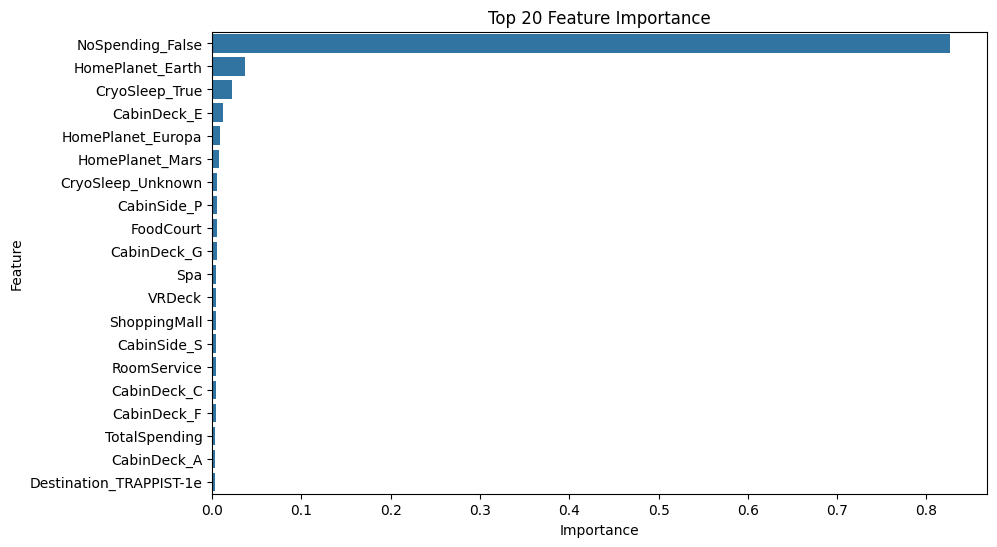

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feature_importance.head(20)

plt.figure(figsize=(10,6))
sns.barplot(x=top_features.values, y=top_features.index)

plt.title("Top 20 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## analisi grafico

- NoSpending_False domina ⇒ il modello sta usando tantissimo “ha speso qualcosa” vs “zero spese”.
- Questo è normale su Spaceship Titanic ed è anche un segnale che Optuna può spremere ancora un po’ di performance regolando profondità/learning rate/regularizzazione.

## Ottimizzazione di XGBoost con Optuna (One-Hot)

In questo step utilizziamo **Optuna** per cercare automaticamente una buona combinazione di iperparametri per XGBoost.

Cosa facciamo:
1. definiamo una funzione `objective(trial)` che:
   - campiona un set di iperparametri (learning rate, depth, n_estimators, ecc.)
   - addestra il modello sul training set
   - valuta l'accuracy sul validation/test set
2. creiamo uno **study** che massimizza l'accuracy
3. abilitiamo il **pruning**: interrompe i tentativi che stanno andando male, risparmiando tempo
4. alla fine otteniamo i **best params** e ri-addestriamo un modello finale con quei parametri

In [42]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 7.0 MB/s eta 0:00:00


In [43]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Nota: usiamo X_train, X_test, y_train, y_test già creati con One-Hot

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
        "random_state": 42,
        "eval_metric": "logloss",
    }

    model_opt = XGBClassifier(**params)

    # pruning: usiamo una eval_set e early stopping
    model_opt.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )

    y_pred = model_opt.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return acc

pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=0)
study = optuna.create_study(direction="maximize", pruner=pruner)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Best Accuracy:", study.best_value)
print("Best Params:")
print(study.best_params)

[I 2026-03-04 15:07:07,205] A new study created in memory with name: no-name-b597694e-2698-4629-9f5a-3b936951c5df


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-04 15:07:08,022] Trial 0 finished with value: 0.8050603795284647 and parameters: {'n_estimators': 461, 'max_depth': 8, 'learning_rate': 0.011688686258391867, 'subsample': 0.9407072732655909, 'colsample_bytree': 0.8589904868441263, 'min_child_weight': 12, 'gamma': 4.620574530818189, 'reg_alpha': 0.6519448724054566, 'reg_lambda': 1.8540292025360527}. Best is trial 0 with value: 0.8050603795284647.
[I 2026-03-04 15:07:09,044] Trial 1 finished with value: 0.8067855089131685 and parameters: {'n_estimators': 1052, 'max_depth': 3, 'learning_rate': 0.0303895635908966, 'subsample': 0.8813887082581466, 'colsample_bytree': 0.8520685477184552, 'min_child_weight': 7, 'gamma': 4.194804620521471, 'reg_alpha': 4.265531133553032, 'reg_lambda': 9.265971111506815}. Best is trial 1 with value: 0.8067855089131685.
[I 2026-03-04 15:07:09,930] Trial 2 finished with value: 0.80448533640023 and parameters: {'n_estimators': 985, 'max_depth': 6, 'learning_rate': 0.16866930276216513, 'subsample': 0.867

## Modello finale con i migliori iperparametri

Ora addestriamo un nuovo modello XGBoost usando i parametri migliori trovati da Optuna
e rivalutiamo le metriche (accuracy, report e confusion matrix).

Final Accuracy: 0.824036802760207

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       863
           1       0.83      0.82      0.83       876

    accuracy                           0.82      1739
   macro avg       0.82      0.82      0.82      1739
weighted avg       0.82      0.82      0.82      1739



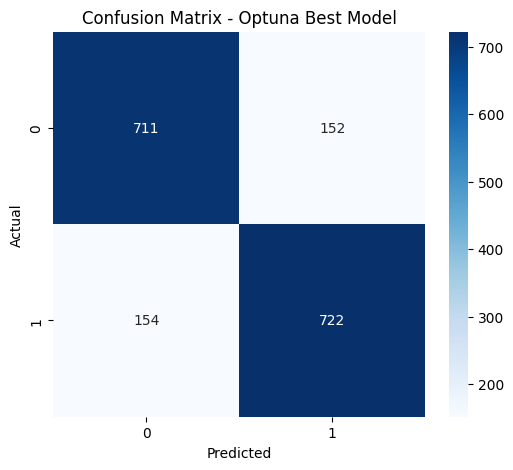

In [44]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_params = study.best_params
best_params["random_state"] = 42
best_params["eval_metric"] = "logloss"

final_model = XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Final Accuracy:", acc)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Optuna Best Model")
plt.show()

## Ottimizzazione degli iperparametri con Optuna

Per migliorare le prestazioni del modello XGBoost è stata utilizzata la libreria **Optuna**, che permette di eseguire una ricerca automatica degli iperparametri.

Optuna esplora lo spazio dei parametri eseguendo più tentativi (trials) e valutando le prestazioni del modello ad ogni iterazione.

Gli iperparametri ottimali trovati sono:

- n_estimators: 613
- max_depth: 8
- learning_rate: 0.096
- subsample: 0.638
- colsample_bytree: 0.624
- min_child_weight: 6
- gamma: 0.94
- reg_alpha: 0.895
- reg_lambda: 4.206

---

### Prestazioni del modello ottimizzato

Accuracy finale:

0.824

Questo rappresenta un miglioramento rispetto al modello baseline (~0.819).

---

### Analisi della Confusion Matrix

| Actual / Predicted | 0 | 1 |
|---|---|---|
| 0 | 711 | 152 |
| 1 | 154 | 722 |

Interpretazione:

- **711** passeggeri non trasportati classificati correttamente
- **722** passeggeri trasportati classificati correttamente
- errori distribuiti in modo bilanciato tra le due classi

---

### Classification Report

| Classe | Precision | Recall | F1 |
|------|------|------|------|
| Non trasportati | 0.82 | 0.82 | 0.82 |
| Trasportati | 0.83 | 0.82 | 0.83 |

Il modello mantiene un comportamento **equilibrato tra le classi**, senza bias evidenti.

---

### Conclusioni

L'ottimizzazione tramite Optuna ha prodotto:

- un leggero miglioramento dell'accuracy
- un modello più robusto grazie alla regolazione degli iperparametri
- prestazioni bilanciate tra le due classi

Questo modello rappresenta la versione finale utilizzata per generare le predizioni della competizione.

# Vediamo dei grafici riassuntivi

## Distribuzione delle predizioni del modello

Visualizziamo la distribuzione delle classi predette dal modello confrontandola con la distribuzione reale del dataset di test.

Questo grafico permette di osservare:

- se il modello tende a favorire una classe
- se la distribuzione delle predizioni è coerente con quella reale
- eventuali bias nella classificazione

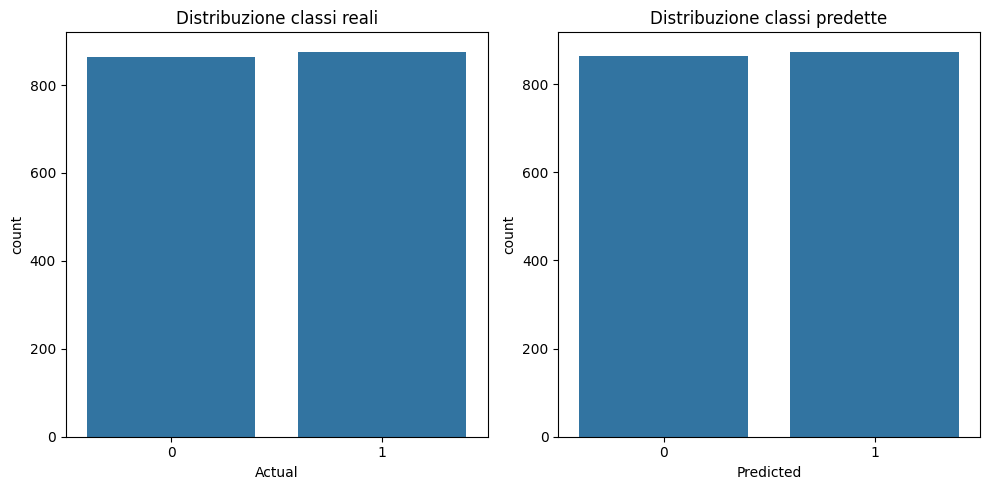

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.countplot(x="Actual", data=results_df)
plt.title("Distribuzione classi reali")

plt.subplot(1,2,2)
sns.countplot(x="Predicted", data=results_df)
plt.title("Distribuzione classi predette")

plt.tight_layout()
plt.show()

## Analisi degli errori del modello

Analizziamo le tipologie di errore del modello:

- **True Positive**: passeggeri trasportati correttamente identificati
- **True Negative**: passeggeri non trasportati correttamente identificati
- **False Positive**: passeggeri classificati come trasportati ma non lo sono
- **False Negative**: passeggeri classificati come non trasportati ma in realtà lo sono

Questa visualizzazione permette di comprendere meglio il comportamento del modello.

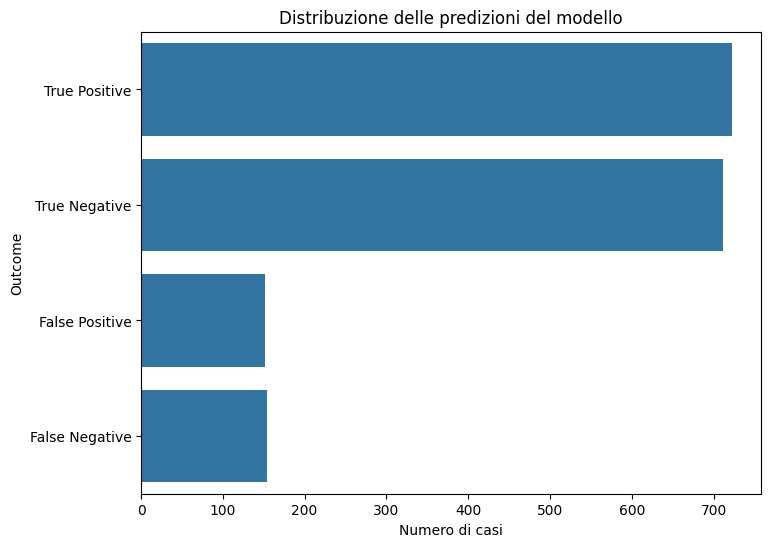

In [46]:
results_df["Outcome"] = "Correct"

results_df.loc[(results_df.Actual == 1) & (results_df.Predicted == 1), "Outcome"] = "True Positive"
results_df.loc[(results_df.Actual == 0) & (results_df.Predicted == 0), "Outcome"] = "True Negative"
results_df.loc[(results_df.Actual == 0) & (results_df.Predicted == 1), "Outcome"] = "False Positive"
results_df.loc[(results_df.Actual == 1) & (results_df.Predicted == 0), "Outcome"] = "False Negative"

plt.figure(figsize=(8,6))
sns.countplot(y="Outcome", data=results_df,
              order=["True Positive","True Negative","False Positive","False Negative"])

plt.title("Distribuzione delle predizioni del modello")
plt.xlabel("Numero di casi")
plt.show()

## Confidenza delle predizioni

Analizziamo la probabilità predetta dal modello per la classe "Transported".

Il modello XGBoost restituisce una probabilità associata alla predizione.  
Visualizzare questa distribuzione permette di capire quanto il modello è sicuro delle sue decisioni.

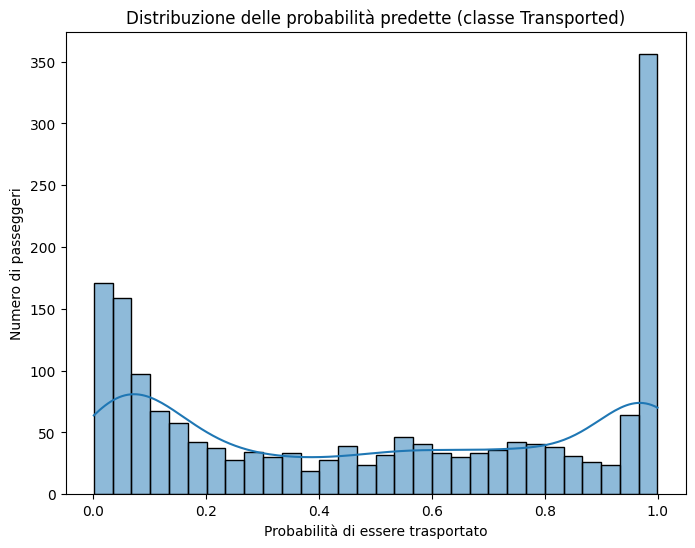

In [47]:
y_prob = final_model.predict_proba(X_test)[:,1]

plt.figure(figsize=(8,6))
sns.histplot(y_prob, bins=30, kde=True)

plt.title("Distribuzione delle probabilità predette (classe Transported)")
plt.xlabel("Probabilità di essere trasportato")
plt.ylabel("Numero di passeggeri")

plt.show()